
# Data Load


In [4]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

%matplotlib inline
pd.set_option('display.max_columns', None)
print("Libraries Loaded")

Libraries Loaded


In [8]:
#load data

df= pd.read_csv('data/AB_NYC_2019.csv')
print(f' Dataset shape:{df.shape}')
df.head()

 Dataset shape:(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [9]:
#quick overview 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     


# EDA


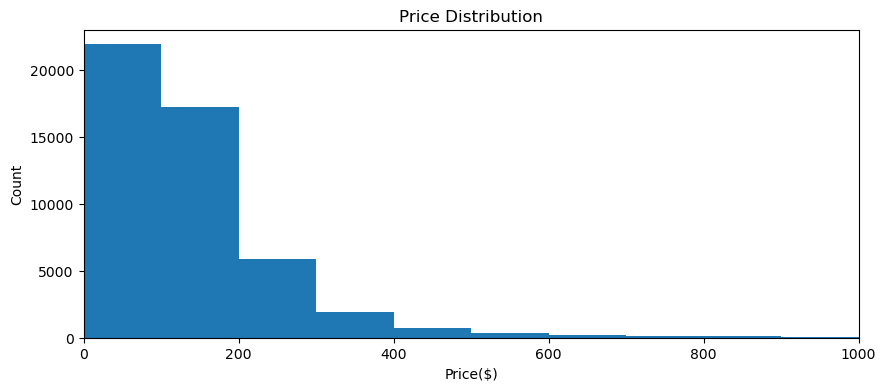

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


In [33]:
#Price distribution - to check for any skewness and stats

plt.figure(figsize=(10,4))
plt.hist(df['price'], bins=100)
plt.title('Price Distribution')
plt.xlabel('Price($)')
plt.ylabel('Count')
plt.xlim(0,1000)
plt.show()

print(df['price'].describe())

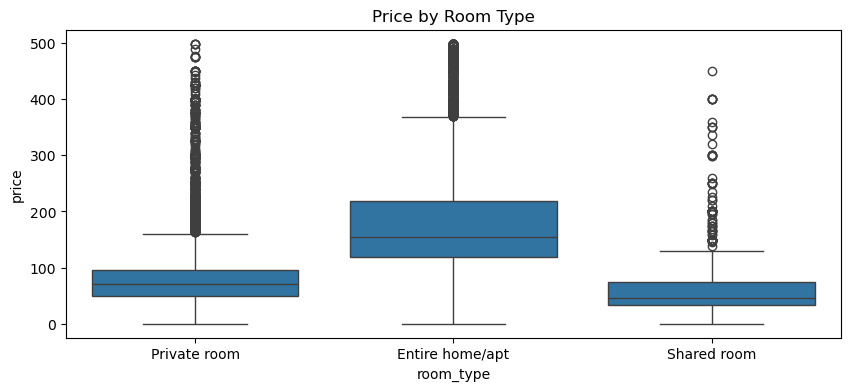

In [20]:
#Price by room-type

plt.figure(figsize=(10,4))
sns.boxplot(x='room_type', y='price' , data=df[df['price']<500])
plt.title('Price by Room Type')
plt.show()

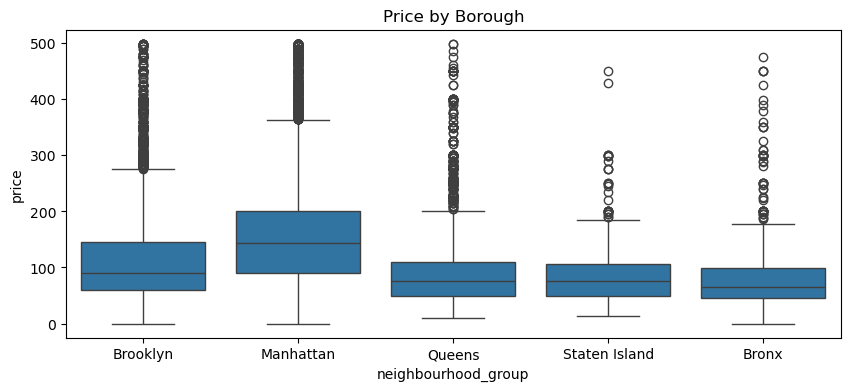

In [21]:
#Price by borough

plt.figure(figsize=(10, 4))
sns.boxplot(x='neighbourhood_group', y='price', data=df[df['price'] < 500])
plt.title('Price by Borough')
plt.show()

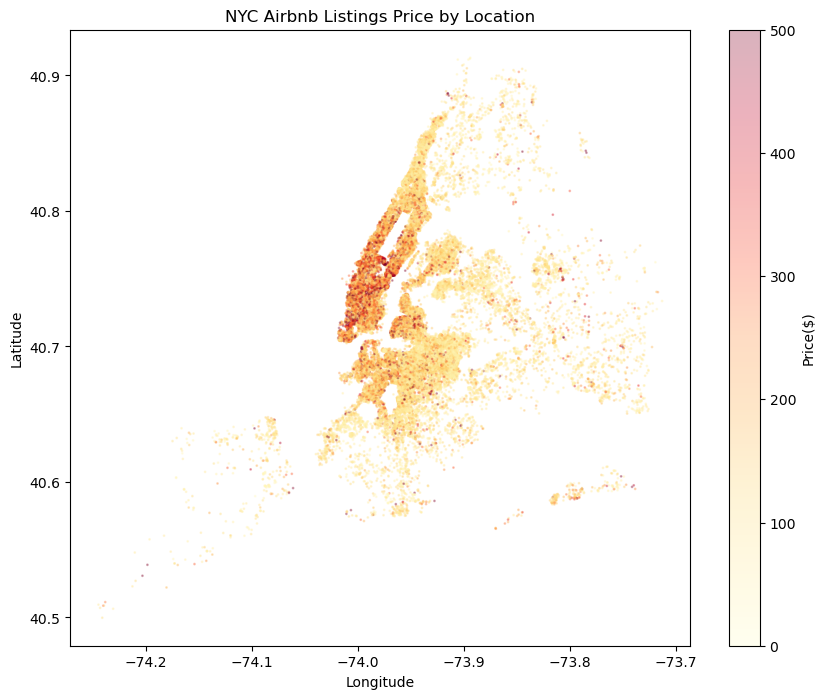

In [32]:
#map plot

plt.figure(figsize=(10,8))
plt.scatter(df['longitude'], df['latitude'],cmap='YlOrRd', c=df['price'].clip(0,500),alpha=0.3, s=1)
plt.colorbar(label='Price($)')
plt.title('NYC Airbnb Listings Price by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# Data Preparation


In [39]:
#remove bad prices - outlier filtering

df=df[ (df['price']>0) & (df['price'] <= 1000) ]
print(f'Remaining Rows: {df.shape[0]} ')


Remaining Rows: 48645 


In [45]:
#drop irrelevant columns like identifiers

df= df.drop(columns= ['id', 'name', 'host_id', 'host_name', 'last_review'])
print (f' Remaining Columns : {df.columns.tolist()}' )

 Remaining Columns : ['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


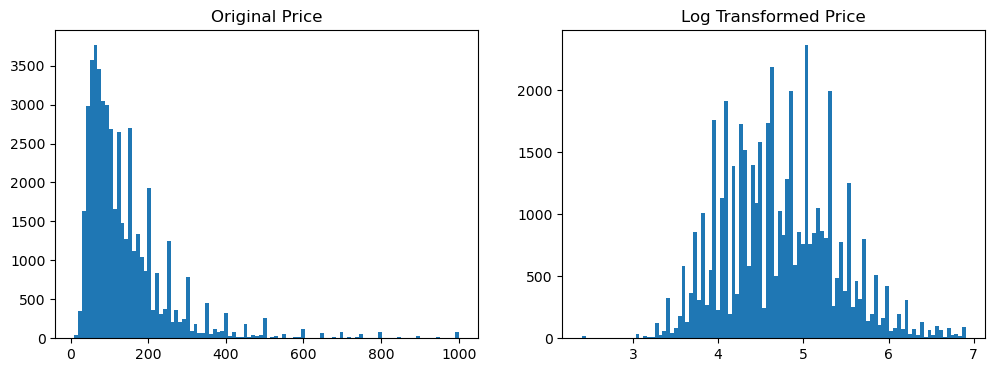

In [48]:
#log transform price - to manage skewness

df['price_log'] = np.log1p(df['price'])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(df['price'], bins =100 )
plt.title('Original Price')

plt.subplot(1,2,2)
plt.hist(df['price_log'], bins=100)
plt.title('Log Transformed Price')

plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

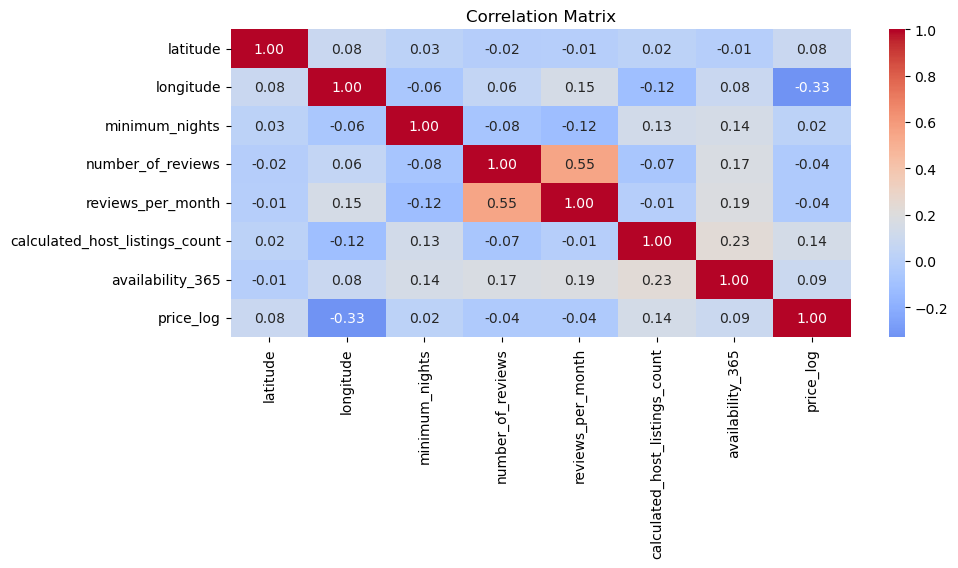

In [65]:
#Correlation heatmap
plt.figure(figsize=(10,4))
corr_matrix = df[['latitude', 'longitude', 'minimum_nights',
                   'number_of_reviews', 'reviews_per_month',
                   'calculated_host_listings_count', 
                   'availability_365', 'price_log']].corr()

sns.heatmap(corr_matrix,annot=True, fmt='.2f', cmap='coolwarm',center=0.2)
plt.title('Correlation Matrix')

In [51]:
#Train-test split

from sklearn.model_selection import train_test_split

#Define features and target
X = df.drop(columns=['price', 'price_log'])
y=df['price_log']

#80% train , 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42)

print(f' Training Set Size : {X_train.shape}')
print(f' Test Set Size : {X_test.shape}')



 Training Set Size : (38916, 10)
 Test Set Size : (9729, 10)


In [66]:
#Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Define which columns are numerical and which are categorical
num_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365']

cat_features = ['neighbourhood_group', 'neighbourhood', 'room_type']

# Numerical pipeline: fill nulls with median, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: fill nulls, then one-hot encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both into one ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print("Pipeline defined")

Pipeline defined



# Train Models


In [70]:
#Linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lin_reg=Pipeline([('preprocessor', preprocessor),('model', LinearRegression())])
lin_reg.fit(X_train,y_train)

#Evaluate on training set
y_pred_train =lin_reg.predict(X_train)
rmse_train=np.sqrt(mean_squared_error(y_train,y_pred_train))
print(f' Linear regression train RMSE: {rmse_train:.4f}')



 Linear regression train RMSE: 0.4323


In [71]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

tree_reg=Pipeline([('preprocessor', preprocessor),('model', DecisionTreeRegressor(random_state=42))])
tree_reg.fit(X_train, y_train)

#Evaluate on training set
y_pred_train = tree_reg.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f' Decision Tree Train RMSE: {rmse_train:.4f}')


 Decision Tree Train RMSE: 0.0012


In [72]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor

forest_reg=Pipeline([ ('preprocessor', preprocessor),('model', RandomForestRegressor(n_estimators=100, random_state=42)) ])
forest_reg.fit(X_train, y_train)

#Evaluate on training set
y_pred_train = forest_reg.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f' Random Forest Train RMSE: {rmse_train:.4f}')


 Random Forest Train RMSE: 0.1513



# Cross Validation on all 3 models


In [73]:
from sklearn.model_selection import cross_val_score

def evaluate_model(model, X, y, name):
    scores=cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)

    rmse_scores=np.sqrt(-scores)
    print(f' \n {name}')
    print(f'  RMSE scores: {rmse_scores.round(4)}')
    print(f'  Mean RMSE:   {rmse_scores.mean():.4f}')
    print(f'  Std Dev:     {rmse_scores.std():.4f}')

evaluate_model(lin_reg, X_train, y_train, "Linear Regression")
evaluate_model(tree_reg, X_train, y_train, "Decision Tree")
evaluate_model(forest_reg, X_train, y_train, "Random Forest")

 
 Linear Regression
  RMSE scores: [0.4302 0.438  0.4361 0.4369 0.4392]
  Mean RMSE:   0.4361
  Std Dev:     0.0031
 
 Decision Tree
  RMSE scores: [0.5638 0.564  0.563  0.5679 0.5712]
  Mean RMSE:   0.5660
  Std Dev:     0.0031
 
 Random Forest
  RMSE scores: [0.4026 0.4076 0.4046 0.4056 0.412 ]
  Mean RMSE:   0.4065
  Std Dev:     0.0032


In [75]:
#GridSearchCV 

from sklearn.model_selection import GridSearchCV

param_grid={
    'model__n_estimators':[50,100],
    'model__max_depth':[10,20,None],
    'model__max_features':['sqrt','log2']
}

grid_search = GridSearchCV(forest_reg, param_grid, cv=3, scoring='neg_mean_squared_error', return_train_score=True,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print(f' Best parameters: {grid_search.best_params_}' )
print(f' Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}' )

 Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
 Best CV RMSE: 0.4060


In [77]:
#Re-training with best parameters

best_model = grid_search.best_estimator_

y_test_pred=best_model.predict(X_test)
test_rmse=np.sqrt(mean_squared_error(y_test,y_test_pred))
print(f' Final Test RMSE: {test_rmse: .4f}')

 Final Test RMSE:  0.4001



# Feature Importance 


In [78]:
#Extract feature names after OneHotEncoding

cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']

cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
all_feature_names = num_features + list(cat_feature_names)

print(f"Total features after encoding: {len(all_feature_names)}") 




Total features after encoding: 232


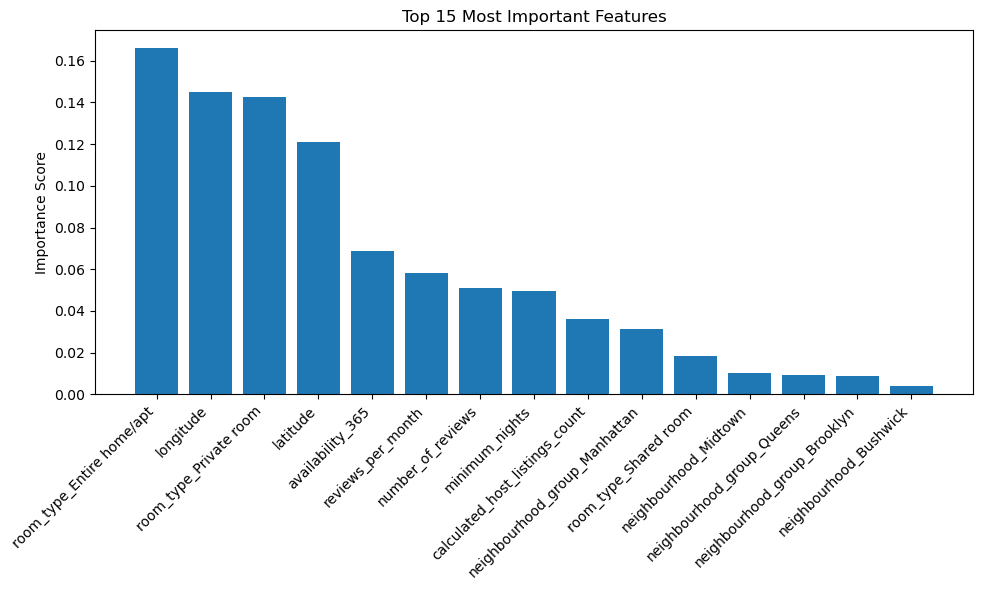

In [79]:
#Plot feature importance

importances = best_model.named_steps['model'].feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), importances[indices[:top_n]])
plt.xticks(range(top_n), [all_feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.title('Top 15 Most Important Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


In [80]:
#print top 10 as a table

print("Top 10 Features:")
print("-" * 40)
for i in range(10):
    idx = indices[i]
    print(f"{i+1:2}. {all_feature_names[idx]:<40} {importances[idx]:.4f}")

Top 10 Features:
----------------------------------------
 1. room_type_Entire home/apt                0.1663
 2. longitude                                0.1451
 3. room_type_Private room                   0.1428
 4. latitude                                 0.1210
 5. availability_365                         0.0685
 6. reviews_per_month                        0.0582
 7. number_of_reviews                        0.0508
 8. minimum_nights                           0.0497
 9. calculated_host_listings_count           0.0361
10. neighbourhood_group_Manhattan            0.0312



# Saving Model


In [81]:
import joblib
import os

joblib.dump(best_model, 'models/airbnb_price_predictor.pkl')
print('Model Saved')

Model Saved


In [85]:
#Load and verify it works

loaded_model=joblib.load('models/airbnb_price_predictor.pkl')

#test on 5 random listings on test set
sample = X_test.iloc[:5]
predictions_log=loaded_model.predict(sample)
predictions_actual=np.expm1(predictions_log)       #converts back from logs to dollars

actual_prices= np.expm1(y_test.iloc[:5])

print('Predicted vs Actual prices:')
print("-" * 35)
for i, (pred, actual) in enumerate(zip(predictions_actual, actual_prices)):
    print(f"Listing {i+1}: Predicted ${pred:.0f}  |  Actual ${actual:.0f}")

Predicted vs Actual prices:
-----------------------------------
Listing 1: Predicted $141  |  Actual $99
Listing 2: Predicted $222  |  Actual $225
Listing 3: Predicted $238  |  Actual $268
Listing 4: Predicted $72  |  Actual $47
Listing 5: Predicted $122  |  Actual $250
